# 01 · Numbers, errors and reporting results

Every computed engineering result carries three kinds of error:

| Error | Source | Controlled by |
|---|---|---|
| **Round-off** | computers store ~16 significant digits | algorithm design |
| **Truncation** | approximating a limit, integral or series | step size / number of terms |
| **Measurement uncertainty** | the input data themselves | instruments, repetition |

This notebook shows all three, then how to *report* a result honestly.

**What you will learn**

- distinguish round-off, truncation and measurement errors
- choose a sensible finite-difference step
- propagate uncertainties linearly and by Monte Carlo, and read an uncertainty budget
- report a result with significant figures consistent with its uncertainty

**Before you start:** notebook 00; partial derivatives; mean and standard deviation  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

## 1. Round-off: floating-point numbers are not real numbers

In [2]:
print(0.1 + 0.2 == 0.3, 0.1 + 0.2)
print(np.finfo(float).eps, "= machine epsilon (relative spacing of doubles)")

False 0.30000000000000004
2.220446049250313e-16 = machine epsilon (relative spacing of doubles)


**Catastrophic cancellation.** The quadratic formula $x = (-b + \sqrt{b^2 - 4ac})/2a$ subtracts two
nearly equal numbers when $b^2 \gg 4ac$. The algebraically identical form
$x = 2c/(-b - \sqrt{b^2-4ac})$ avoids the subtraction.

In [3]:
a, b, c = 1.0, 1e8, 1.0      # small root is -1e-8 (to 16 digits: -1.0000000000000000e-08)
naive = (-b + np.sqrt(b*b - 4*a*c)) / (2*a)
stable = 2*c / (-b - np.sqrt(b*b - 4*a*c))
print(f"naive  {naive:.16e}\nstable {stable:.16e}")

naive  -7.4505805969238281e-09
stable -1.0000000000000000e-08


The naive result is wrong already in its first digit - an error of 25 %, from a formula that is
algebraically exact. Rearranging formulas to avoid subtracting nearly
equal quantities is a core numerical skill.

## 2. Truncation versus round-off: the finite-difference step
A derivative approximated by $[f(x+h) - f(x)]/h$ has truncation error $\propto h$ but round-off
error $\propto \varepsilon/h$. Too large a step is inaccurate; too small a step is *also* inaccurate.

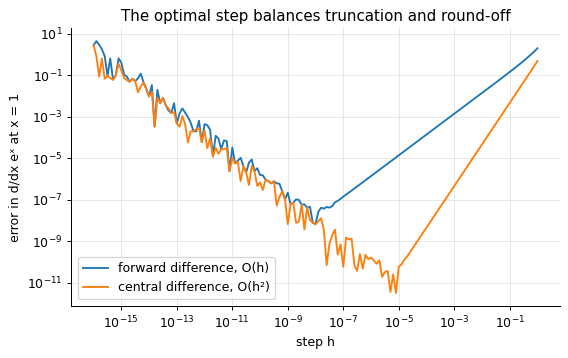

best forward step ~ 1e-08 (theory ~ sqrt(eps) = 1e-08)
best central step ~ 8e-06 (theory ~ eps^(1/3) = 6e-06)


In [4]:
h = np.logspace(-16, 0, 161)
x0 = 1.0
err_fwd = np.abs(engmath.differentiate.forward(np.exp, x0, h) - np.exp(x0))
err_cen = np.abs(engmath.differentiate.central(np.exp, x0, h) - np.exp(x0))
fig, ax = plt.subplots()
ax.loglog(h, err_fwd, label="forward difference, O(h)")
ax.loglog(h, err_cen, label="central difference, O(h²)")
ax.set(xlabel="step h", ylabel="error in d/dx eˣ at x = 1", title="The optimal step balances truncation and round-off")
ax.legend(); plt.show()
print(f"best forward step ~ {h[np.nanargmin(err_fwd)]:.0e} (theory ~ sqrt(eps) = {np.sqrt(np.finfo(float).eps):.0e})")
print(f"best central step ~ {h[np.nanargmin(err_cen)]:.0e} (theory ~ eps^(1/3) = {np.finfo(float).eps**(1/3):.0e})")

## 3. Measurement uncertainty and its propagation

**Problem.** The hydraulic efficiency of a pump is
$$\eta = \frac{\rho g Q H}{P}$$
from measured flow $Q$, head $H$ and shaft power $P$. With independent inputs, first-order
propagation gives $u^2(\eta) = \sum_i (\partial\eta/\partial x_i)^2 u^2(x_i)$.

In [5]:
def efficiency(Q, H, P, rho=998.0, g=9.81):
    return rho * g * Q * H / P

values = {"Q": 0.0125, "H": 32.0, "P": 5200.0}     # m3/s, m, W
unc    = {"Q": 0.0002, "H": 0.4,  "P": 60.0}       # standard uncertainties
eta, u_eta, share = engmath.reporting.propagate(efficiency, values, unc)
print(f"efficiency = {eta:.4f}, u = {u_eta:.4f}")
for k, s in share.items():
    print(f"  {k}: {100*s:4.1f} % of the variance")

efficiency = 0.7531, u = 0.0176
  Q: 46.9 % of the variance
  H: 28.6 % of the variance
  P: 24.4 % of the variance


## Inside the algorithm: first-order propagation
Each sensitivity coefficient $c_i = \partial\eta/\partial x_i$ is estimated by a central difference, and the
contributions $(c_i u_i)^2$ are added:

In [6]:
def propagate_by_hand(func, values, unc):
    y0 = func(**values)
    variance = 0.0
    for name, x in values.items():
        h = 1e-6 * abs(x)
        up = {**values, name: x + h}
        down = {**values, name: x - h}
        c = (func(**up) - func(**down)) / (2 * h)      # sensitivity coefficient
        variance += (c * unc[name])**2
    return y0, float(np.sqrt(variance))

print("by hand:", propagate_by_hand(efficiency, values, unc))
print("library:", engmath.reporting.propagate(efficiency, values, unc)[:2])

by hand: (0.753106153846154, 0.017587666699305032)
library: (0.753106153846154, 0.017587666699305032)


The flow measurement dominates: even a perfect power meter would only reduce $u(\eta)$ from 0.018 to
0.015, whereas halving the flow-meter uncertainty would do more. **Uncertainty budgets
tell you where to spend money.**

### Checking the linear approximation with Monte Carlo
Draw many random input sets, compute $\eta$ for each, and look at the spread.

Monte Carlo: mean 0.7531, standard deviation 0.0176


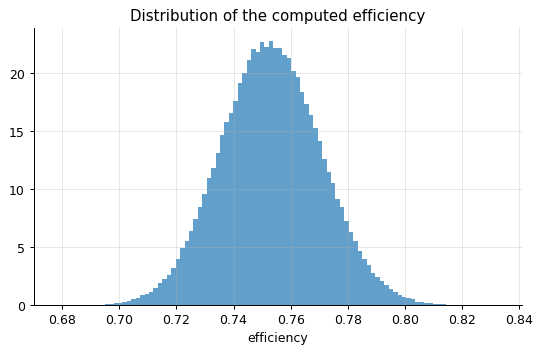

In [7]:
rng = np.random.default_rng(1)
N = 200_000
samples = efficiency(rng.normal(values["Q"], unc["Q"], N),
                     rng.normal(values["H"], unc["H"], N),
                     rng.normal(values["P"], unc["P"], N))
print(f"Monte Carlo: mean {samples.mean():.4f}, standard deviation {samples.std(ddof=1):.4f}")
plt.hist(samples, bins=100, density=True, alpha=0.7)
plt.xlabel("efficiency"); plt.title("Distribution of the computed efficiency"); plt.show()

Both methods agree because the relative uncertainties are small. When they are large, or the model
is strongly nonlinear, Monte Carlo is the safer choice (see also the companion library
[engstat](https://github.com/ktwyw/engstat) for GUM budgets with degrees of freedom).

## 4. Reporting: significant figures follow the uncertainty
Round the uncertainty to one significant figure (two if it starts with 1), then round the value to
the same decimal place.

In [8]:
from engmath.reporting import format_uncertainty
print("pump efficiency:", format_uncertainty(eta, u_eta))
for v, u in [(2.29987, 0.08907), (10523.4, 156.7), (0.0001234, 0.0000123), (51.66, 1.23)]:
    print(f"{v} ± {u}  ->  {format_uncertainty(v, u)}")

pump efficiency: 0.753 ± 0.018
2.29987 ± 0.08907  ->  2.30 ± 0.09
10523.4 ± 156.7  ->  10520 ± 160
0.0001234 ± 1.23e-05  ->  (1.23 ± 0.12)e-04
51.66 ± 1.23  ->  51.7 ± 1.2


## Exercises
1. Compute $\ln(1+x)$ for $x = 10^{-12}$ directly and with `np.log1p`. Explain the difference.
2. A heat exchanger duty is $\dot{Q} = \dot{m} c_p (T_{out} - T_{in})$ with $T_{in} = 20.0 \pm 0.2$ °C and
   $T_{out} = 24.0 \pm 0.2$ °C. Why is the relative uncertainty of $\dot{Q}$ so large? Redesign the
   measurement to reduce it.
3. Use Monte Carlo to find the uncertainty of $\eta$ if the power meter uncertainty were 20 %. Is the
   distribution still symmetric?
4. **Implement it yourself:** extend `propagate_by_hand` to correlated inputs, $u^2 = \sum_i\sum_j c_i u_i\, R_{ij}\, c_j u_j$ with a correlation matrix $R$. How does $u(\eta)$ change if the errors in $Q$ and $H$ have correlation $+0.5$? And $-0.5$?